In [52]:
import pedpy
import pathlib
import matplotlib.pyplot as plt
import shapely

# Preprocessing

Pedpy provides functions for preprocessing, such as:

1. Outlier detection
2. Correct invalid trajectories


## Outlier detection

Pedpy provides a function, that detects and corrects outliers and also detects drops within the trajectory, which happen, when the tracking of a certain person is interrupted and the tracker continues to track another person instead.

The algorithm for detecting outliers splits the trajectory into multiple dataframes, one per person and calculates every distance between two following points. The expected distance is the 99% quantile between two following distances multiplied with the tolerance. A low value for this parameter means a low tolerance for potential outliers, which can be useful in trajectories where the speed of the pedestrians stays in a similar range. If the pedestrians speed variates, for example in bottleneck experiments, the tolerance should be chosen larger.

In [53]:
trajectory_data = pedpy.load_trajectory(
    trajectory_file=pathlib.Path("demo-data/preprocessing/uni_corr_500_08_modified.txt"),
        default_unit=pedpy.TrajectoryUnit.METER,
    )
trajectory_data_corrected, changed_index_orig, changed_index_new  = (
        pedpy.detect_outliers(
            trajectory_data,
            tolerance=6)
)

INFO - Outliers found: personID 55 at frames [2018] 
INFO - Outliers found: personID 89 at frames [438] 
INFO - Outliers found: personID 123 at frames [3081, 3082, 3083, 3084, 3085, 3086, 3087] 
INFO - Outliers found: personID 209 at frames [479, 480, 481, 482, 483, 484, 485, 486, 487, 488, 489, 490] 
INFO - Outliers found: personID 210 at frames [1387, 1388, 1389] 
INFO - Outliers found: personID 211 at frames [1186, 1187, 2055, 2056, 2057, 2058, 2059, 2060, 2061, 2062, 2063, 2064, 2065, 2066, 2067, 2068, 2069, 2070, 2071, 2072, 2073, 2074, 2075, 2076, 2077, 2078] 
INFO - Trajectory with personID 422 has to many invalid points and cannot be corrected
INFO - Trajectory with personID 422 will be returned unchanged
INFO - Outliers found: personID 463 at frames [350, 713, 714, 715, 750, 751, 752, 753, 754, 755, 756, 757, 758, 759, 760, 761, 762, 763, 764, 765, 766] 


Like the tolerance, the quantile for the expected distance can also be chosen manually. This influences the tolerance in a different way.

If in a data set of a certain personID more that percentage_invalid % of all frames were considered outliers, this part of the trajectory is considered invalid. This percentage can be chosen manually too. The function provides the bool parameter deleting, where the user can define, that invalid data sets should be removed in the returned trajectory.

### Drops Only

It is possible only filter for drops in the trajectory by setting drops_only = True. This way outlier, that do not occur at the very beginning or at the very end are ignored and the data sets of certain personIDs are only split after a drop. If outlier happen at the very beginning, those are cut out too.


In [54]:
trajectory_data_corrected, changed_index_orig, changed_index_new  = (
        pedpy.detect_outliers(
        trajectory_data,
        drops_only=True)
)

INFO - Frames in trajectory with original personID 55 were cut out after frame 2017 
INFO - Frames in trajectory with original personID 209 were cut out after frame 478 
INFO - Frames in trajectory with original personID 210 were cut out before frame 1389
INFO - Frames in trajectory with original personID 211 were cut out before frame 1188 and after frame 2054 
INFO - Trajectory with personID 422 has to many invalid points and cannot be corrected
INFO - Trajectory with personID 422 will be returned unchanged
INFO - Frames in trajectory with original personID 463 were cut out before frame 351 and after frame 749 


### Other parameters

max_length: Sometimes it happens, that a few outliers are directly after another without a jump back to the correct trajectory. The max_length value defines, how many points long those multiple outliers can be, before the program will check, whether it is a split in the trajectory or, if the outlier occur at the beginning of the trajectory, the points before it will be treated as outliers. The default value is 8.

critical: Only relevant in cases, where anomalies occur in the beginning of a trajectory and the previous outlier finds need to be checked again, also critical length that a trajectory has to have. If the lowest position of anomalies in the begging is lower than the critical value, the anomalies are considered as outlier. Otherwise, it is a split and the points and every point after is going to be deleted. The default value is 10% of the length of the trajectory.

drops_only: A bool parameter whether the program should only search and correct major jumps within the trajectory, that do not have a jump back. This includes outlier group that contain the very first or the very last frame of the person and drops in the middle of the trajectory, where the tracker caused problems.

In [55]:
traj_data_low_tolerance = (
        pedpy.detect_outliers(
            trajectory_data,
            tolerance=3,
            quantile=0.95,
            percentage_invalid= 0.2,
            deleting= True,
            max_length=10
        )[0]
)

INFO - Outliers found: personID 3 at frames [144, 145, 146, 147, 148, 149, 150, 151] 
INFO - Outliers found: personID 11 at frames [86, 87, 88, 89, 90, 91, 92, 93] 
INFO - Outliers found: personID 29 at frames [3324, 3325] 
INFO - Outliers found: personID 55 at frames [2018] 
INFO - Outliers found: personID 59 at frames [1182, 1183] 
INFO - Outliers found: personID 67 at frames [124, 125, 126, 127, 128, 129, 130, 131] 
INFO - Outliers found: personID 89 at frames [438] 
INFO - Outliers found: personID 117 at frames [1184, 1185] 
INFO - Outliers found: personID 123 at frames [3081, 3082, 3083, 3084, 3085, 3086, 3087] 
INFO - Outliers found: personID 204 at frames [156, 157, 158] 
INFO - Outliers found: personID 209 at frames [479, 480, 481, 482, 483, 484, 485, 486, 487, 488, 489, 490] 
INFO - Outliers found: personID 210 at frames [1387, 1388, 1389] 
INFO - Outliers found: personID 211 at frames [1186, 1187, 2055, 2056, 2057, 2058, 2059, 2060, 2061, 2062, 2063, 2064, 2065, 2066, 2067, 2

### Compare original and corrected trajectory

For every part of the trajectory, where outliers were detected, the corresponding personID and frames, where outlier occurred, are put into the log output. It returns a corrected copy of the input trajectory data. Furthermore, it returns two lists: first, with all the personIDs of those parts in the original trajectory, where anomalies were found and second, the corresponding list of personIDs of the corrected trajectory. In most cases they are the same, only if some personIDs were deleted every following one shifts.

Those lists can be used to plot the parts of the trajectory, to get an impression of the outliers and how they were fixed. The white line is the original trajectory; the blue line is the corrected one.

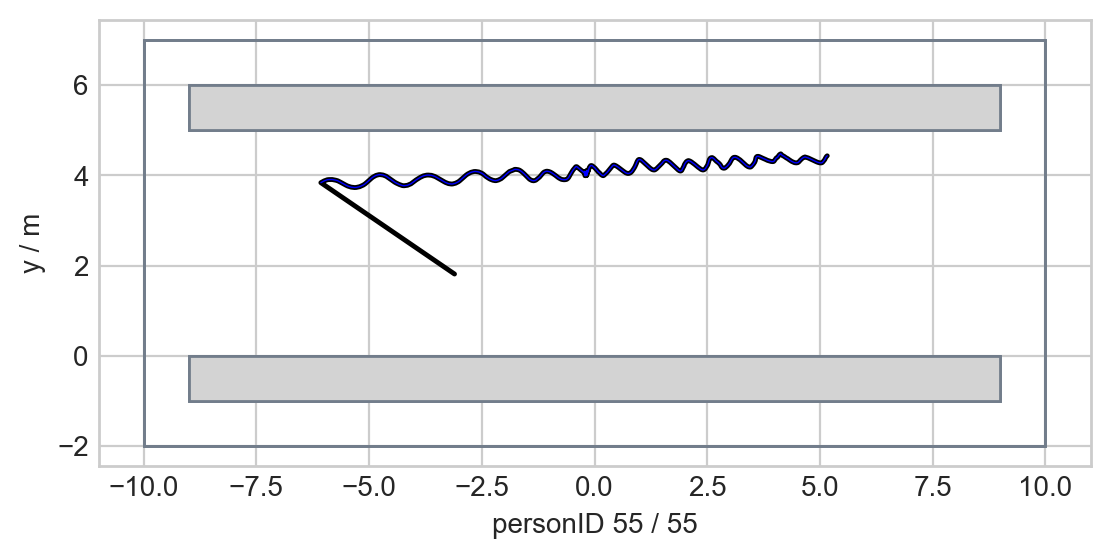

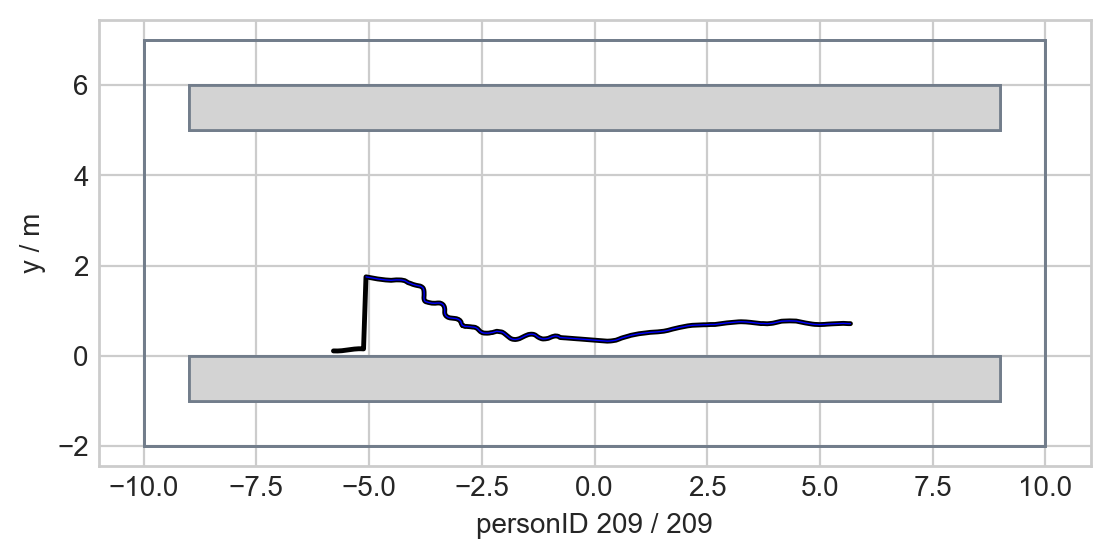

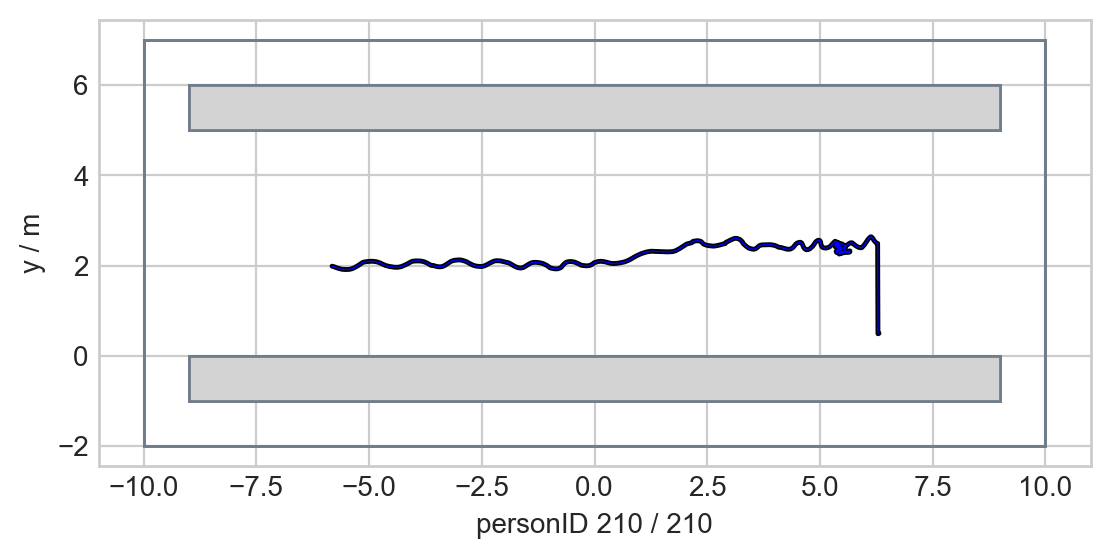

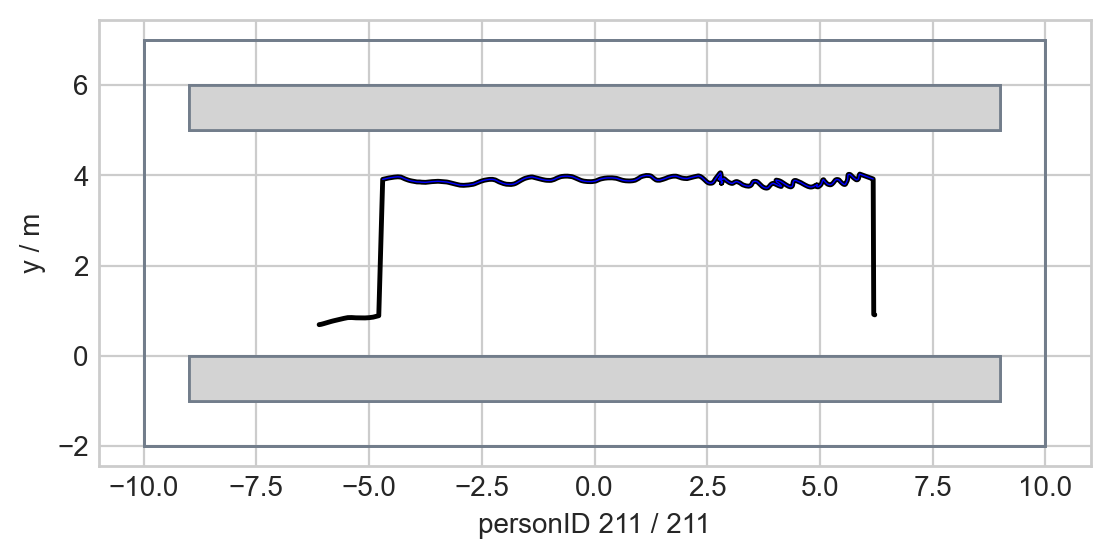

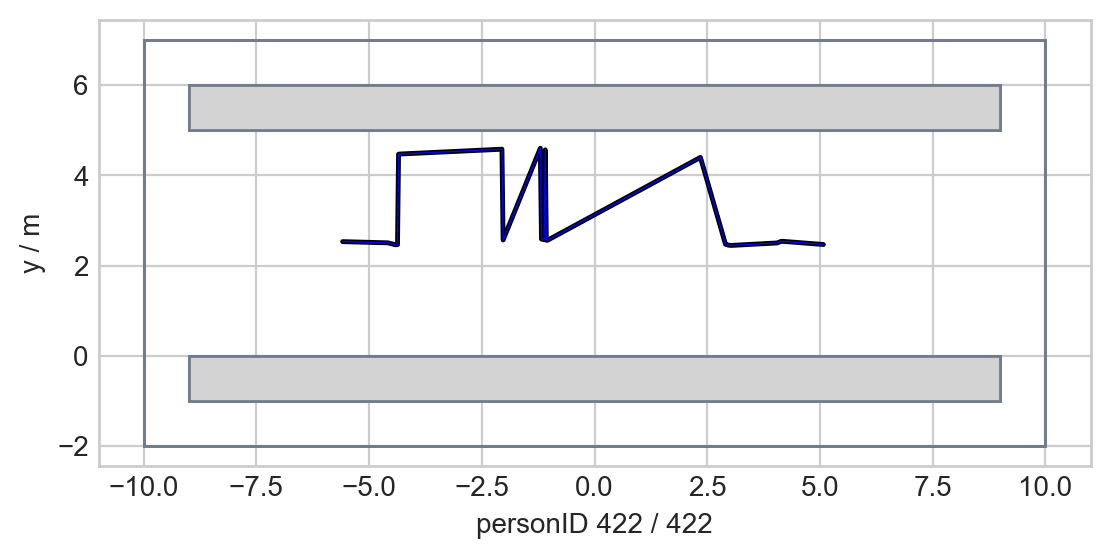

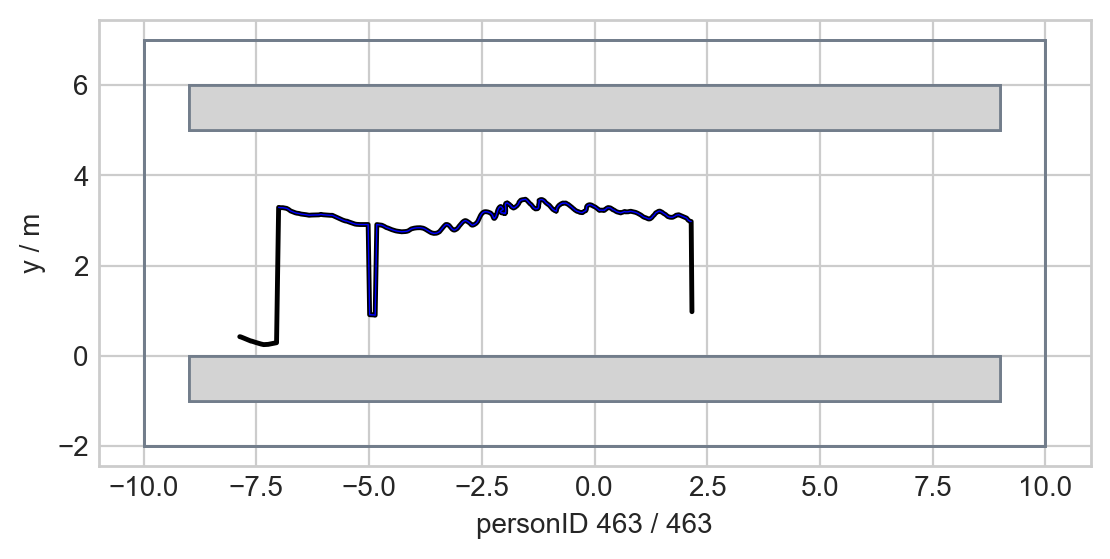

In [56]:
walk_area = pedpy.WalkableArea(shapely.from_wkt("POLYGON ((10 -2, -10 -2, -10 7, 10 7, 10 -2), (9 6, -9 6, -9 5, 9 5, 9 6), (-9 -1, 9 -1, 9 0, -9 0, -9 -1))"))

%config InlineBackend.figure_format = 'retina'


for i in range(len(changed_index_orig)):
    original_trajectory = trajectory_data.data[trajectory_data.data["id"] == changed_index_orig[i]]
    trajectory_corrected = trajectory_data_corrected.data[trajectory_data_corrected.data["id"] == changed_index_new[i]]
    pedpy.plot_trajectories(traj=pedpy.TrajectoryData
    (data=original_trajectory, frame_rate=trajectory_data.frame_rate),
                            walkable_area=walk_area, traj_width=1.75, traj_color='black').set_aspect("equal")
    pedpy.plot_trajectories(traj=pedpy.TrajectoryData
    (data=trajectory_corrected, frame_rate=trajectory_data.frame_rate),
                            walkable_area=walk_area, traj_width=0.5, traj_color='blue').set_aspect("equal")
    plt.xlabel(f"personID {changed_index_orig[i]} / {changed_index_new[i]}")
    plt.show()